## Importando bibliotecas e carregando o dataset

In [1]:
# Carregando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Carregando o dataset

cols = [
    "fact_sales_id", "date_id", "customer_id", "product_id",
    "location_id", "payment_id",
    "quantity", "unit_price", "discount", "shipping_cost", "total_sales"
]

df = pd.read_csv('C:/SQLData/sales_eda_dataset.csv', sep=None, engine="python", header=None, names=cols)

print("✅ Dataset carregado com sucesso!")

print("🎲 Amostragem de informações")
df.sample(5)

✅ Dataset carregado com sucesso!
🎲 Amostragem de informações


,fact_sales_id,date_id,customer_id,product_id,location_id,payment_id,quantity,unit_price,discount,shipping_cost,total_sales
804,805,20260119,C5382,P513,402,3,4,19229.69,0.13,64.33,66983.6512
226,227,20260203,C8415,P586,958,3,3,13699.75,0.19,84.29,33374.6825
1145,1146,20260125,C2359,P829,364,1,3,7665.86,0.16,30.15,19348.1172
2815,2816,20260131,C7317,P322,1448,3,2,44767.16,0.28,106.77,64571.4804
2384,2385,20260109,C4488,P646,1787,2,2,34192.67,0.29,69.10,48622.6914


In [3]:
# Mostrando informações básicas da tabela

print("🔎 Mostrando informações básicas das colunas de vendas")
df[['unit_price','discount','shipping_cost','total_sales']].describe()

🔎 Mostrando informações básicas das colunas de vendas


,unit_price,discount,shipping_cost,total_sales
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,25265.399460,0.148963,84.764310,64397.495294
std,14404.075748,0.087271,37.738786,50956.490462
min,216.910000,0.000000,20.010000,366.509700
25%,12887.947500,0.070000,51.947500,24176.901275
50%,24936.240000,0.150000,85.080000,51811.718600
75%,37995.857500,0.230000,117.585000,92325.372050
max,49980.910000,0.300000,149.950000,240143.046000


In [4]:
# Tranformando valores de datas em um formato manipulável

df['date_id'] = pd.to_datetime(
    df['date_id'].astype(str),
    format='%Y%m%d'
)
print("📶 Datas convertidas com sucesso!")

📶 Datas convertidas com sucesso!


## Análise exploratória sucinta

In [5]:
# Mostrando o total bruto das vendas

print("💎 Qual o total bruto das vendas durante o período?")
gross_total = (df['quantity']*df['unit_price']).sum()
gross_total

💎 Qual o total bruto das vendas durante o período?


np.float64(226675217.51000002)

In [6]:
# Mostrando o valor total das vendas

print("💲 Qual o valor total das vendas no período?")
net_total = df['total_sales'].sum()
net_total

💲 Qual o valor total das vendas no período?


np.float64(193192485.8814)

In [7]:
# Mostrando o total dos descontos

print("💸 Qual o total do valor aplicado nas vendas no período?")
discounts_applied = ((df['quantity']*df['unit_price'])*df['discount']).sum()
discounts_applied

💸 Qual o total do valor aplicado nas vendas no período?


np.float64(33737024.55859999)

In [8]:
# Mostrando os clientes que compraram mais de uma vez

print("🛍 Quantos clientes compraram mais de uma vez durante o período?")
(df['customer_id'].value_counts()>1).sum()

🛍 Quantos clientes compraram mais de uma vez durante o período?


np.int64(401)

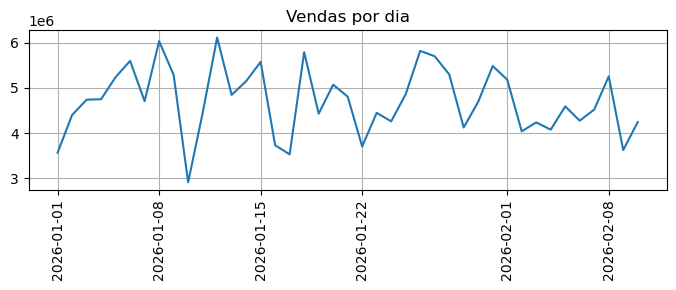

In [10]:
#Análise gráfica das vendas por dia

daily_sales = df.groupby('date_id')['total_sales'].sum()

plt.figure(figsize=(7,3))
plt.plot(daily_sales.index, daily_sales.values)
plt.title('Vendas por dia')
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()

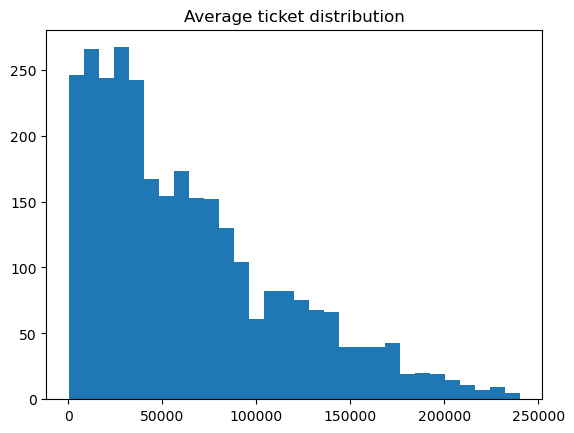

In [11]:
# Mostrar a distribuição do ticket médio

plt.figure()
plt.hist(df['total_sales'], bins=30)
plt.title('Average ticket distribution')
plt.show()